## Import required packages

In [65]:
# import libraries for reading data, exploring and plotting

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# library for train test split
from sklearn.model_selection import train_test_split

# deep learning libraries for text pre-processing
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences# Modeling 
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout, LSTM, Bidirectional


## Loading and Analysis of Data

In [66]:
# Reading the dataset
messages=pd.read_csv("../data/SMSSpamCollection.txt",sep ='\t',names=["label", "message"])
messages[:3]

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [67]:
# Dmessages.groupby('label').describe().Tisplaying the statistics 
messages.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [68]:
# To display the duplicate rows
duplicatedRow = messages[messages.duplicated()]
print(duplicatedRow[:5])

    label                                            message
103   ham  As per your request 'Melle Melle (Oru Minnamin...
154   ham  As per your request 'Melle Melle (Oru Minnamin...
207   ham  As I entered my cabin my PA said, '' Happy B'd...
223   ham                             Sorry, I'll call later
326   ham                   No calls..messages..missed calls


In [69]:
#To checke whether data is balanced or not
messages.groupby('label').describe().T

label                              ham  \
message count                     4825   
        unique                    4516   
        top     Sorry, I'll call later   
        freq                        30   

label                                                        spam  
message count                                                 747  
        unique                                                653  
        top     Please call our customer service representativ...  
        freq                                                    4

In [70]:
# Get all the ham and spam emails
ham_msg = messages[messages.label =='ham']
spam_msg = messages[messages.label=='spam']               # Create numpy list to visualize using wordcloud
ham_msg_text = " ".join(ham_msg.message.to_numpy().tolist())
spam_msg_text = " ".join(spam_msg.message.to_numpy().tolist())

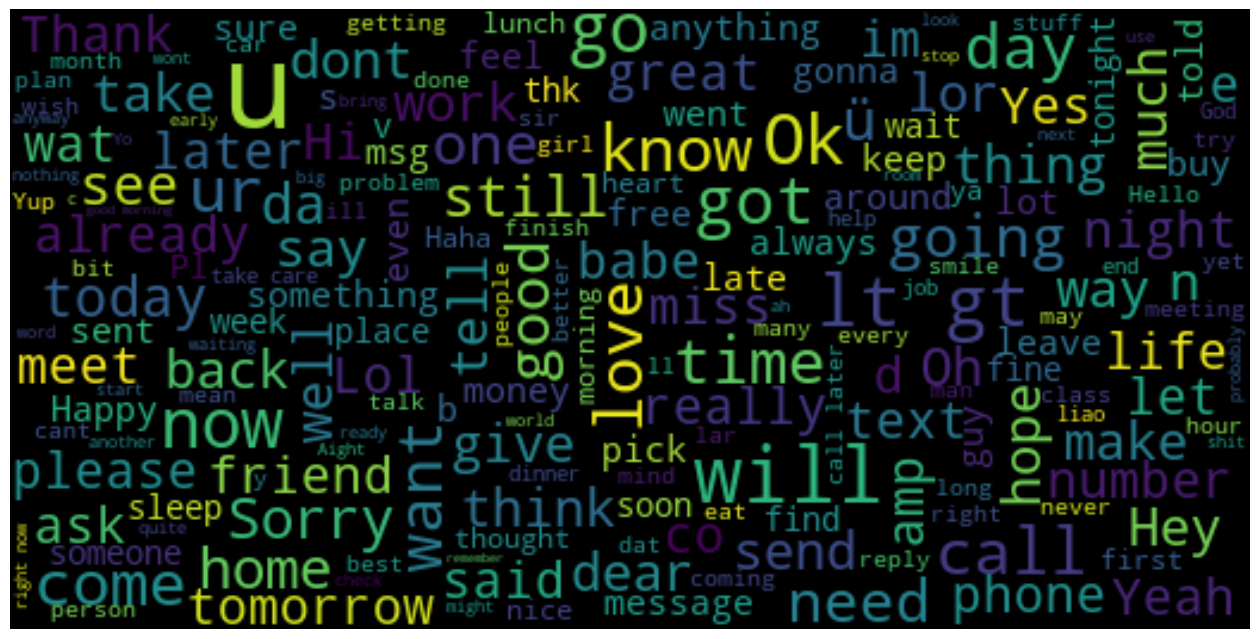

In [71]:
# wordcloud of ham messages
ham_msg_cloud = WordCloud(width =520, height =260, stopwords=STOPWORDS,max_font_size=50, background_color ="black").generate(ham_msg_text)
plt.figure(figsize=(16,10))
plt.imshow(ham_msg_cloud, interpolation='bilinear')
plt.axis('off') # turn off axis
plt.show()

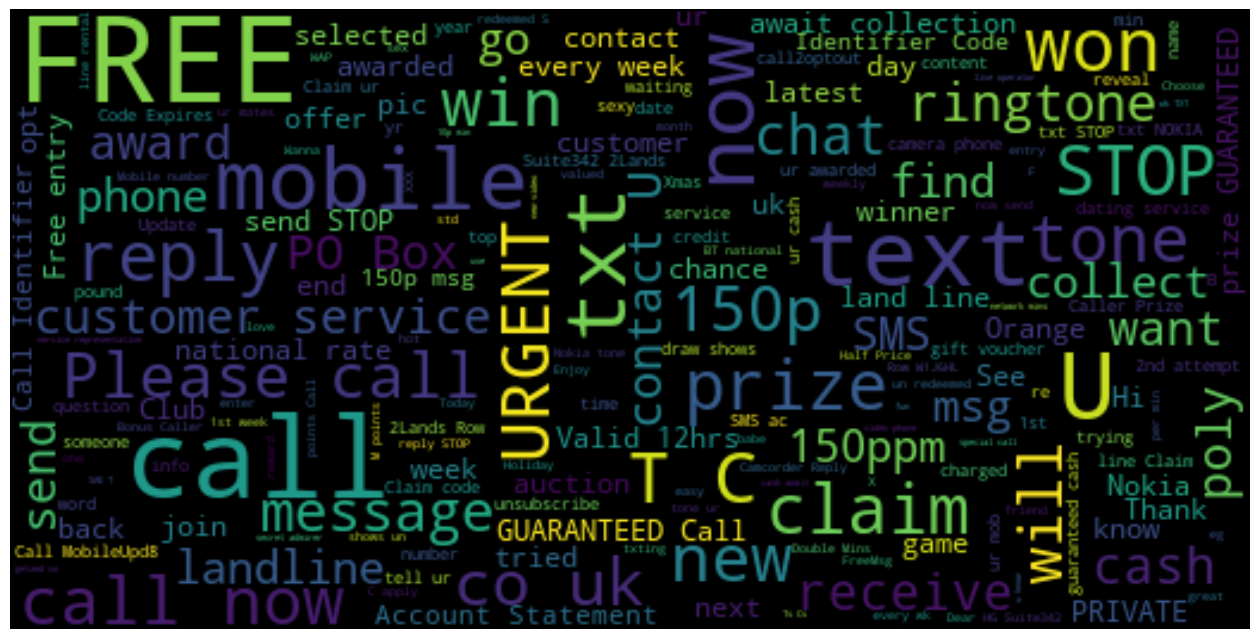

In [72]:
# wordcloud of spam messages
spam_msg_cloud = WordCloud(width =520, height =260, stopwords=STOPWORDS,max_font_size=50, background_color ="black").generate(spam_msg_text)
plt.figure(figsize=(16,10))
plt.imshow(spam_msg_cloud, interpolation='bilinear')
plt.axis('off') # turn off axis
plt.show()

15.481865284974095

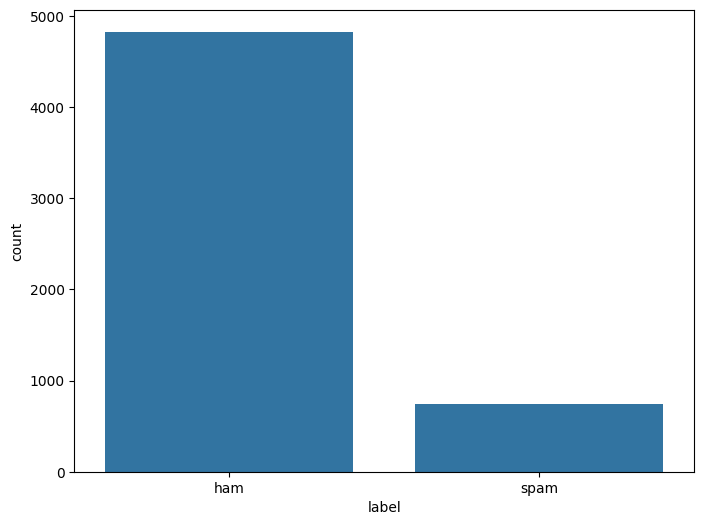

In [73]:
# we can observe imbalance data here 
plt.figure(figsize=(8,6))
sns.countplot(x=messages.label,data=messages)
# Percentage of spam messages
(len(spam_msg)/len(ham_msg))*100 # 15.48%

In [74]:
# one way to fix it is to downsample the ham msg
ham_msg_df = ham_msg.sample(n = len(spam_msg), random_state = 44)
spam_msg_df = spam_msg
print(ham_msg_df.shape, spam_msg_df.shape)

(747, 2) (747, 2)


Text(0.5, 0, 'Message types')

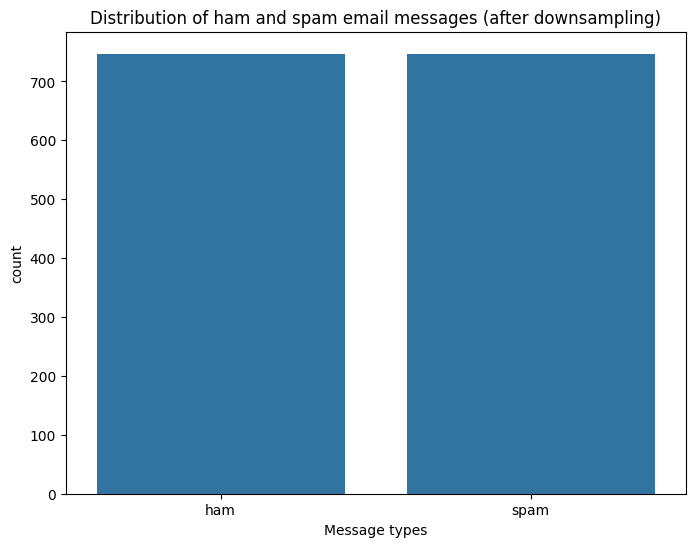

In [75]:
# Create a dataframe with these ham and spam msg
msg_df = pd.concat([ham_msg_df,spam_msg_df]).reset_index(drop=True)
plt.figure(figsize=(8,6))
sns.countplot(x=msg_df.label)
plt.title('Distribution of ham and spam email messages (after downsampling)')
plt.xlabel('Message types')

In [76]:
# Get length column for each text
msg_df['text_length'] = msg_df['message'].apply(len)#Calculate average length by label types
labels = msg_df.groupby('label')['text_length'].mean()
labels

#Average length of ham is 73 and that of spam is 138

label
ham      73.238286
spam    138.670683
Name: text_length, dtype: float64

## Test-Train spliltting and Pre-processing

In [77]:
# Map ham label as 0 and spam as 1
msg_df['msg_type']= msg_df['label'].map({'ham': 0, 'spam': 1})
msg_label = msg_df['msg_type'].values
# Split data into train and test
train_msg, test_msg, train_labels, test_labels = train_test_split(msg_df['message'], msg_label, test_size=0.2, random_state=434)

### Tokenization

In [78]:
# Defining pre-processing hyperparameters
max_len = 50 
trunc_type = "post" 
padding_type = "post" 
oov_tok = "<OOV>" 
vocab_size = 500

In [79]:
tokenizer = Tokenizer(num_words = vocab_size, char_level=False, oov_token = oov_tok)
tokenizer.fit_on_texts(train_msg)
# Get the word_index 
word_index = tokenizer.word_index
word_index

{'<OOV>': 1,
 'to': 2,
 'you': 3,
 'a': 4,
 'i': 5,
 'call': 6,
 'the': 7,
 'u': 8,
 'your': 9,
 'for': 10,
 'is': 11,
 '2': 12,
 'and': 13,
 'now': 14,
 'free': 15,
 'or': 16,
 'on': 17,
 'in': 18,
 'ur': 19,
 'have': 20,
 '4': 21,
 'txt': 22,
 'of': 23,
 'are': 24,
 'with': 25,
 'me': 26,
 'from': 27,
 'text': 28,
 'get': 29,
 'my': 30,
 'it': 31,
 'stop': 32,
 'just': 33,
 'mobile': 34,
 'this': 35,
 'will': 36,
 'be': 37,
 'no': 38,
 'that': 39,
 'claim': 40,
 'reply': 41,
 'can': 42,
 'so': 43,
 'send': 44,
 'www': 45,
 'we': 46,
 'only': 47,
 'our': 48,
 'not': 49,
 'out': 50,
 'at': 51,
 'do': 52,
 'if': 53,
 'prize': 54,
 'new': 55,
 'go': 56,
 'cash': 57,
 'but': 58,
 '150p': 59,
 'uk': 60,
 '1': 61,
 'nokia': 62,
 'who': 63,
 't': 64,
 'all': 65,
 'win': 66,
 'please': 67,
 'won': 68,
 'up': 69,
 'tone': 70,
 'when': 71,
 "i'm": 72,
 'week': 73,
 'been': 74,
 'what': 75,
 'msg': 76,
 '50': 77,
 'com': 78,
 'urgent': 79,
 'how': 80,
 'service': 81,
 'phone': 82,
 'time': 83,
 

In [80]:
# check how many words 
tot_words = len(word_index)
print('There are %s unique tokens in training data. ' % tot_words)

There are 4169 unique tokens in training data. 


### Sequencing & Padding

In [81]:
# Sequencing and padding on training and testing 
training_sequences = tokenizer.texts_to_sequences(train_msg)
training_padded = pad_sequences (training_sequences, maxlen = max_len, padding = padding_type, truncating = trunc_type )
testing_sequences = tokenizer.texts_to_sequences(test_msg)
testing_padded = pad_sequences(testing_sequences, maxlen = max_len,padding = padding_type, truncating = trunc_type)

In [82]:
# Shape of train tensor
print('Shape of training tensor: ', training_padded.shape)
print('Shape of testing tensor: ', testing_padded.shape)

Shape of training tensor:  (1195, 50)
Shape of testing tensor:  (299, 50)


In [83]:
# Before padding length
print(len(training_sequences[0]), len(training_sequences[1]))
# After padding length
print(len(training_padded[0]), len(training_padded[1]))

27 24
50 50


## Dense Spam Detection Model

In [85]:
vocab_size = 500 # As defined earlier
embeding_dim = 16
drop_value = 0.2 # dropout
n_dense = 24
#Dense model architecture
model = Sequential()
model.add(Embedding(vocab_size, embeding_dim, input_length=max_len))
model.add(GlobalAveragePooling1D())
model.add(Dense(24, activation='relu'))
model.add(Dropout(drop_value))
model.add(Dense(1, activation='sigmoid'))
model.summary()
model.compile(loss='binary_crossentropy',optimizer='adam' ,metrics=['accuracy'])
# fitting a dense spam detector model
num_epochs = 50
early_stop = EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(training_padded, train_labels, epochs=num_epochs, validation_data=(testing_padded, test_labels),callbacks =[early_stop], verbose=2)
model.save('../models/Dense_Spam_Detection.h5')

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
38/38 - 2s - 65ms/step - accuracy: 0.4946 - loss: 0.6723 - val_accuracy: 0.5652 - val_loss: 0.6473
Epoch 2/50
38/38 - 0s - 3ms/step - accuracy: 0.6904 - loss: 0.6192 - val_accuracy: 0.7291 - val_loss: 0.5858
Epoch 3/50
38/38 - 0s - 4ms/step - accuracy: 0.7824 - loss: 0.5454 - val_accuracy: 0.8127 - val_loss: 0.5221
Epoch 4/50
38/38 - 0s - 4ms/step - accuracy: 0.8301 - loss: 0.4696 - val_accuracy: 0.8294 - val_loss: 0.4631
Epoch 5/50
38/38 - 0s - 3ms/step - accuracy: 0.8519 - loss: 0.4114 - val_accuracy: 0.8328 - val_loss: 0.4202
Epoch 6/50
38/38 - 0s - 4ms/step - accuracy: 0.8636 - loss: 0.3679 - val_accuracy: 0.8428 - val_loss: 0.3763
Epoch 7/50
38/38 - 0s - 3ms/step - accuracy: 0.8870 - loss: 0.3203 - val_accuracy: 0.8595 - val_loss: 0.3347
Epoch 8/50
38/38 - 0s - 4ms/step - accuracy: 0.8946 - loss: 0.2904 - val_accuracy: 0.8829 - val_loss: 0.2935
Epoch 9/50
38/38 - 0s - 3ms/step - accuracy: 0.9063 - loss: 0.2547 - val_accuracy: 0.8896 - val_loss: 0.2626
Epoch 10/50
38/38 

In [86]:
# Model performance on test data 
model.evaluate(testing_padded, test_labels)
# Read as a dataframe 
metrics = pd.DataFrame(history.history)
# Rename column
metrics.rename(columns = {'loss': 'Training_Loss', 'accuracy': 'Training_Accuracy', 'val_loss': 'Validation_Loss', 'val_accuracy': 'Validation_Accuracy'}, inplace = True)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9365 - loss: 0.1470 


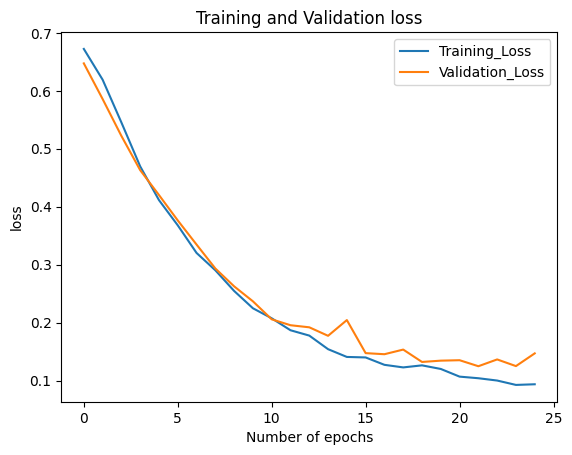

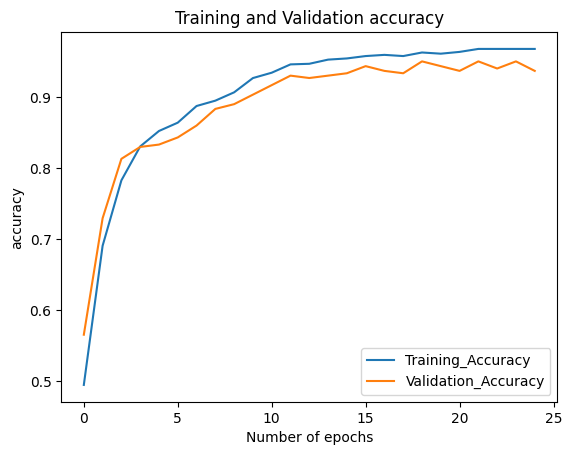

In [87]:
def plot_graphs1(var1, var2, string):
    metrics[[var1, var2]].plot()
    plt.title('Training and Validation ' + string)
    plt.xlabel ('Number of epochs')
    plt.ylabel(string)
    plt.legend([var1, var2])
plot_graphs1('Training_Loss', 'Validation_Loss', 'loss')
plot_graphs1('Training_Accuracy', 'Validation_Accuracy', 'accuracy')

## Long Short Term Memory (LSTM) Model

In [88]:
#LSTM hyperparameters
n_lstm = 20
drop_lstm =0.2

#LSTM Spam detection architecture
model1 = Sequential()
model1.add(Embedding(vocab_size, embeding_dim, input_length=max_len))
model1.add(LSTM(n_lstm, dropout=drop_lstm))#return_sequences=True is giving error due to wrong dimensions 
model1.add(Dense(1, activation='sigmoid'))
model1.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics=['accuracy'])
num_epochs = 30
early_stop = EarlyStopping(monitor='val_loss', patience=5)
history = model1.fit(training_padded, train_labels, epochs=num_epochs, validation_data=(testing_padded, test_labels),callbacks =[early_stop], verbose=2)
model1.save('../models/LSTM_Spam_Detection.h5')

Epoch 1/30


d:\All_Jupyter_Work\Spam_Shield\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


38/38 - 2s - 55ms/step - accuracy: 0.5163 - loss: 0.6931 - val_accuracy: 0.4716 - val_loss: 0.6923
Epoch 2/30
38/38 - 0s - 10ms/step - accuracy: 0.6854 - loss: 0.6268 - val_accuracy: 0.8528 - val_loss: 0.4695
Epoch 3/30
38/38 - 0s - 11ms/step - accuracy: 0.8937 - loss: 0.3570 - val_accuracy: 0.8428 - val_loss: 0.4641
Epoch 4/30
38/38 - 0s - 11ms/step - accuracy: 0.9063 - loss: 0.3093 - val_accuracy: 0.9365 - val_loss: 0.2418
Epoch 5/30
38/38 - 0s - 10ms/step - accuracy: 0.8971 - loss: 0.3337 - val_accuracy: 0.9264 - val_loss: 0.2625
Epoch 6/30
38/38 - 0s - 11ms/step - accuracy: 0.9297 - loss: 0.2564 - val_accuracy: 0.8863 - val_loss: 0.3621
Epoch 7/30
38/38 - 0s - 10ms/step - accuracy: 0.9222 - loss: 0.2708 - val_accuracy: 0.9097 - val_loss: 0.2833
Epoch 8/30
38/38 - 0s - 11ms/step - accuracy: 0.9431 - loss: 0.2105 - val_accuracy: 0.9331 - val_loss: 0.2329
Epoch 9/30
38/38 - 0s - 11ms/step - accuracy: 0.9565 - loss: 0.1741 - val_accuracy: 0.9431 - val_loss: 0.2154
Epoch 10/30
38/38 - 0

In [89]:
model1.evaluate(testing_padded, test_labels)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9365 - loss: 0.2140 


[0.21403232216835022, 0.9364548325538635]

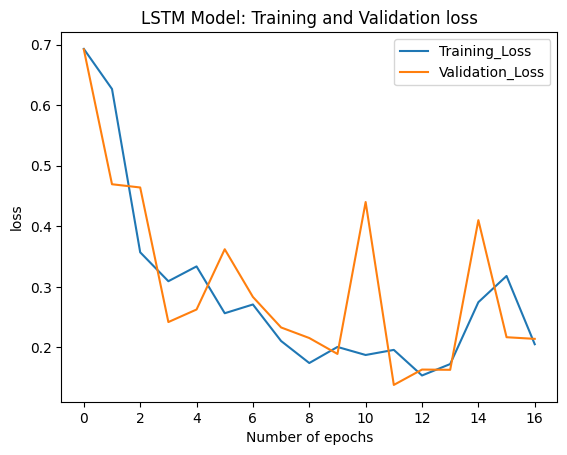

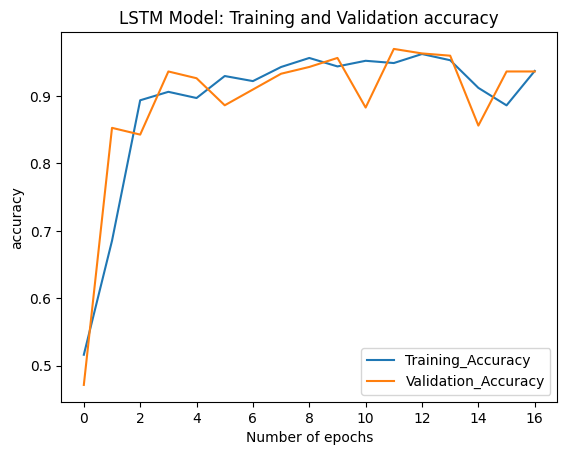

In [90]:
# Create a dataframe
metrics = pd.DataFrame(history.history)# Rename column
metrics.rename(columns = {'loss': 'Training_Loss', 'accuracy': 'Training_Accuracy',
                         'val_loss': 'Validation_Loss', 'val_accuracy': 'Validation_Accuracy'}, inplace = True)
def plot_graphs1(var1, var2, string):
    metrics[[var1, var2]].plot()
    plt.title('LSTM Model: Training and Validation ' + string)
    plt.xlabel ('Number of epochs')
    plt.ylabel(string)
    plt.legend([var1, var2])
plot_graphs1('Training_Loss', 'Validation_Loss', 'loss')
plot_graphs1('Training_Accuracy', 'Validation_Accuracy', 'accuracy')

## Support Vector Machine

In [91]:
from sklearn.svm import SVC

# SVC hyperparameters
C = 10
gamma = 0.1
kernel = 'rbf'

# SVM Spam detection
svm_model = SVC(C=C, gamma=gamma, kernel=kernel)
svm_model.fit(training_padded, train_labels)
score = svm_model.score(testing_padded, test_labels)

print("Accuracy:", score)


Accuracy: 0.6956521739130435


In [92]:
model1.evaluate(testing_padded, test_labels)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9365 - loss: 0.2140 


[0.21403232216835022, 0.9364548325538635]

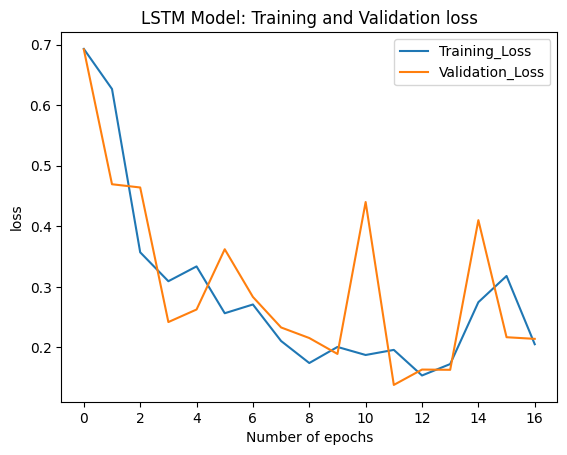

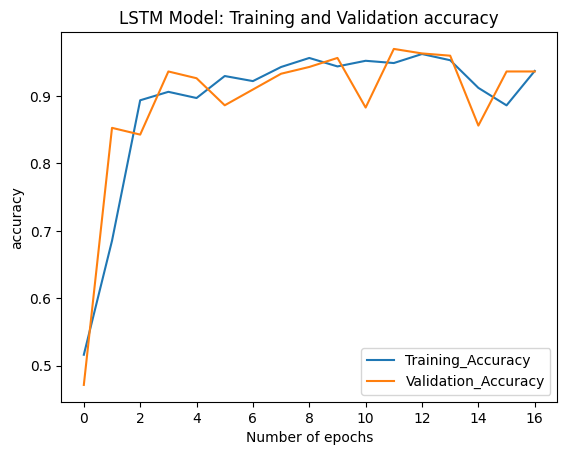

In [93]:
# Create a dataframe
metrics = pd.DataFrame(history.history)# Rename column
metrics.rename(columns = {'loss': 'Training_Loss', 'accuracy': 'Training_Accuracy',
                         'val_loss': 'Validation_Loss', 'val_accuracy': 'Validation_Accuracy'}, inplace = True)
def plot_graphs1(var1, var2, string):
    metrics[[var1, var2]].plot()
    plt.title('LSTM Model: Training and Validation ' + string)
    plt.xlabel ('Number of epochs')
    plt.ylabel(string)
    plt.legend([var1, var2])
plot_graphs1('Training_Loss', 'Validation_Loss', 'loss')
plot_graphs1('Training_Accuracy', 'Validation_Accuracy', 'accuracy')

## Bi-directional Long Short Term Memory (BiLSTM) Model

In [94]:
# Biderectional LSTM Spam detection architecture
model2 = Sequential()
model2.add(Embedding(vocab_size, embeding_dim, input_length=max_len))
model2.add(Bidirectional(LSTM(n_lstm, dropout=drop_lstm)))
model2.add(Dense(1, activation='sigmoid'))
model2.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics=['accuracy'])
# Training
num_epochs = 30
early_stop = EarlyStopping(monitor='val_loss', patience=4)
history = model2.fit(training_padded, train_labels, epochs=num_epochs, 
                    validation_data=(testing_padded, test_labels),callbacks =[early_stop], verbose=2)
model2.save('../models/Bi-LSTM_spam_detection.h5')

Epoch 1/30


d:\All_Jupyter_Work\Spam_Shield\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


38/38 - 3s - 86ms/step - accuracy: 0.6494 - loss: 0.6595 - val_accuracy: 0.8194 - val_loss: 0.5463
Epoch 2/30
38/38 - 1s - 15ms/step - accuracy: 0.8485 - loss: 0.4399 - val_accuracy: 0.8428 - val_loss: 0.4037
Epoch 3/30
38/38 - 1s - 16ms/step - accuracy: 0.8879 - loss: 0.3075 - val_accuracy: 0.9030 - val_loss: 0.2641
Epoch 4/30
38/38 - 1s - 15ms/step - accuracy: 0.9431 - loss: 0.1777 - val_accuracy: 0.9264 - val_loss: 0.2078
Epoch 5/30
38/38 - 1s - 15ms/step - accuracy: 0.9565 - loss: 0.1280 - val_accuracy: 0.9398 - val_loss: 0.1860
Epoch 6/30
38/38 - 1s - 17ms/step - accuracy: 0.9649 - loss: 0.1062 - val_accuracy: 0.9666 - val_loss: 0.1050
Epoch 7/30
38/38 - 1s - 15ms/step - accuracy: 0.9715 - loss: 0.0883 - val_accuracy: 0.9766 - val_loss: 0.0934
Epoch 8/30
38/38 - 1s - 15ms/step - accuracy: 0.9757 - loss: 0.0765 - val_accuracy: 0.9565 - val_loss: 0.1199
Epoch 9/30
38/38 - 1s - 16ms/step - accuracy: 0.9782 - loss: 0.0671 - val_accuracy: 0.9732 - val_loss: 0.0919
Epoch 10/30
38/38 - 1

In [95]:
model2.evaluate(testing_padded, test_labels)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9398 - loss: 0.2052 


[0.2052331566810608, 0.9397993087768555]

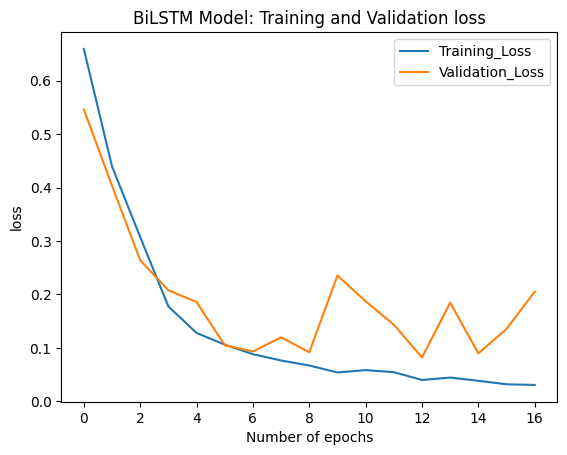

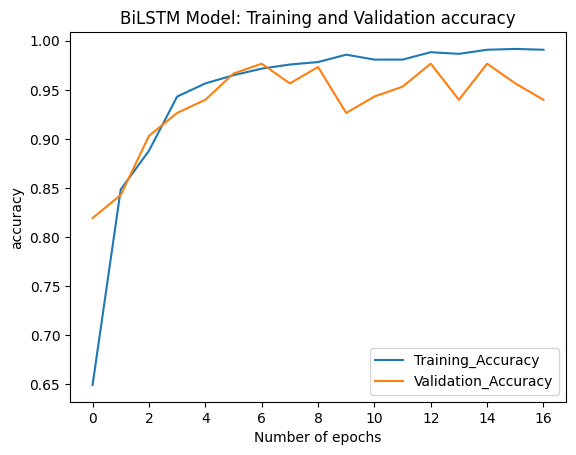

In [96]:
# Create a dataframe
metrics = pd.DataFrame(history.history)# Rename column
metrics.rename(columns = {'loss': 'Training_Loss', 'accuracy': 'Training_Accuracy',
                         'val_loss': 'Validation_Loss', 'val_accuracy': 'Validation_Accuracy'}, inplace = True)
def plot_graphs1(var1, var2, string):
    metrics[[var1, var2]].plot()
    plt.title('BiLSTM Model: Training and Validation ' + string)
    plt.xlabel ('Number of epochs')
    plt.ylabel(string)
    plt.legend([var1, var2])# Plot
plot_graphs1('Training_Loss', 'Validation_Loss', 'loss')
plot_graphs1('Training_Accuracy', 'Validation_Accuracy', 'accuracy')